                    All Data
                       |
              Try many possible
                   splits
                       |
        ┌──────────────┼──────────────┐
        ↓              ↓              ↓
     Split A        Split B        Split C
        ↓              ↓              ↓
   Calculate       Calculate       Calculate
   impurity        impurity        impurity
        ↓              ↓              ↓
        └──────────────┼──────────────┘
                       ↓
                 Best split

. Weighted Gini Impurity
There is an important detail.

After splitting the data, we don't simply calculate the Gini of each group and choose the smallest one.

We calculate a weighted impurity

In [2]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini"
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini")


In [3]:
model = DecisionTreeClassifier(
    criterion="entropy"
)

In [28]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd 

# Load data
iris = load_iris(as_frame=True)
df = iris.frame


X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)


Accuracy: 1.0


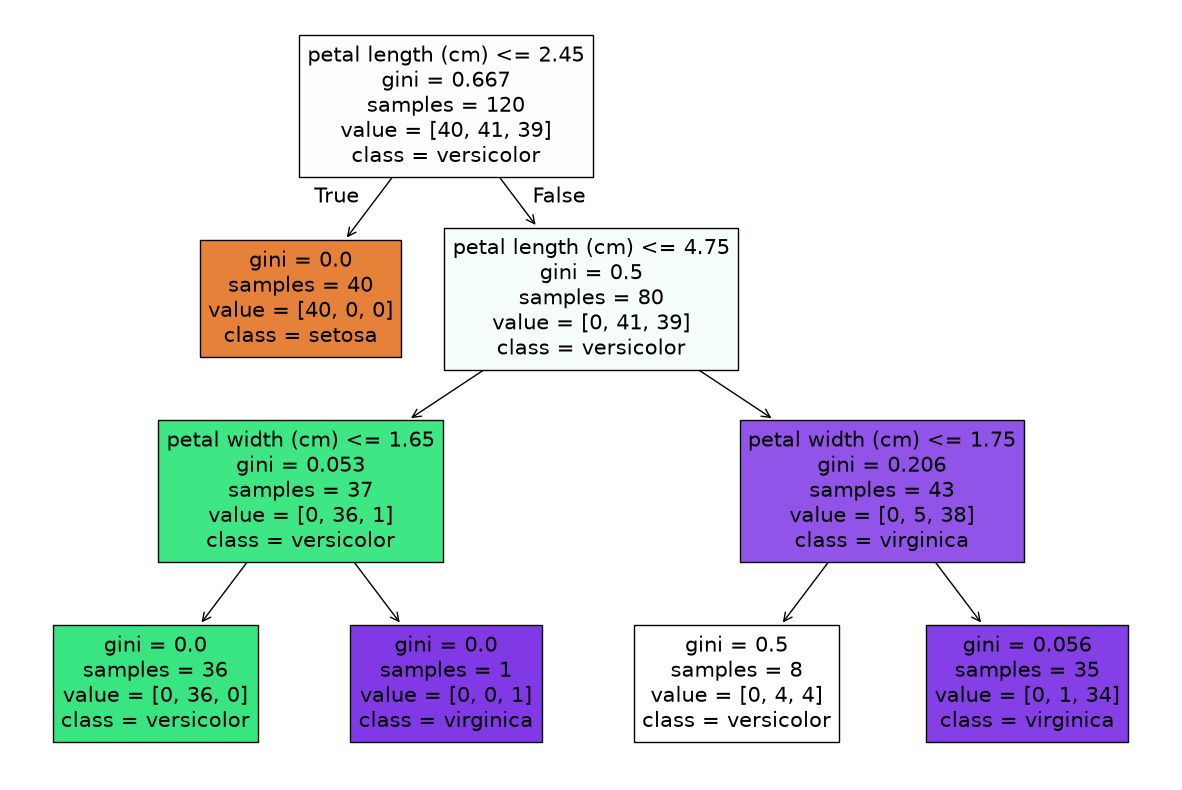

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Iris dataset
     ↓
X and y
     ↓
Train/Test Split
     ↓
DecisionTreeClassifier
     ↓
fit()
     ↓
predict()
     ↓
accuracy_score()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [21]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [24]:
print(model.feature_importances_)
print(model.feature_importances_)

[0.01695274 0.         0.90455226 0.078495  ]
[0.01695274 0.         0.90455226 0.078495  ]


In [26]:
probabilities = model.predict_proba(X_test)
probabilities 

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

| Parameter           | Meaning                                |
| ------------------- | -------------------------------------- |
| `criterion`         | How split quality is measured          |
| `max_depth`         | Maximum depth                          |
| `min_samples_split` | Minimum samples needed to split        |
| `min_samples_leaf`  | Minimum samples in a leaf              |
| `max_leaf_nodes`    | Maximum number of leaves               |
| `ccp_alpha`         | Cost-complexity pruning                |
| `random_state`      | Makes randomized behavior reproducible |


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

parameters = {
    "max_depth": [2, 3, 4, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    model,
    parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


                 DATA
                   ↓
             X and y
                   ↓
            Find candidate
                splits
                   ↓
        Calculate split quality
          /              \
       Gini            Entropy
          \              /
           ↓            ↓
             Best split
                  ↓
               Split data
                  ↓
          ┌───────┴───────┐
          ↓               ↓
       Split again      Split again
          ↓               ↓
        Continue until stopping
             conditions
                  ↓
                Leaves
                  ↓
              Prediction
                  ↓
             Evaluation
                  ↓
       Check generalization
                  ↓
        Tune/prune if needed

Decision Tree
Root
Node
Leaf
Split
Mathematics
Gini impurity
Entropy
Information Gain
Weighted impurity
Machine Learning
Classification
Regression
Training
Prediction
Evaluation
Controlling complexity
max_depth
min_samples_split
min_samples_leaf
max_leaf_nodes
ccp_alpha
Evaluation
Accuracy
Precision
Recall
F1
Confusion Matrix
Cross-validation
Interpretation
Feature importance
Tree visualization
Decision boundaries
Main problem
Overfitting
     ↓
Control tree complexity
     ↓
Better generalization

What is a Decision Tree?

A good answer is:

A Decision Tree is a supervised Machine Learning algorithm that learns a sequence of feature-based decisions to divide data into increasingly homogeneous groups and use the resulting leaves to make predictions.

In very easy English:

A Decision Tree learns questions from data and uses those questions to make a prediction